In [34]:
from scipy.stats import norm
from scipy.stats import beta
import numpy as np
import matplotlib.pyplot as plt

# Simulación con el algoritmo de metropolis

Supondre fronteras periodicas por lo que los elementos de los extremos de las filas y columnas son vecinos de los extremos contrarios. Mire que el algoritmo solo necesita saber si aumento o disminuyo la energia, por lo que puedo simplemente calcular el cambio en la energia, no tengo que acalcular la energia completa.

El cambio de energía asociado a la inversión del espín $s_{ij}$ se obtiene comparando la energía después y antes de invertirlo. Si el espín cambia como

$$
s_{ij} \longrightarrow -s_{ij},
$$

entonces la diferencia de energía es

$$
\Delta E =
s_{ij}
\left(
J \sum_{\text{vecinos}} s_{\text{vecino}} + H
\right)
-
\left[
-s_{ij}
\left(
J \sum_{\text{vecinos}} s_{\text{vecino}} + H
\right)
\right].
$$

Factorizando los términos semejantes, se obtiene

$$
\Delta E =
s_{ij}
\left(
J \sum_{\text{vecinos}} s_{\text{vecino}} + H
\right)
+
s_{ij}
\left(
J \sum_{\text{vecinos}} s_{\text{vecino}} + H
\right).
$$

Por lo tanto,

$$
\boxed{
\Delta E =
2s_{ij}
\left(
J \sum_{\text{vecinos}} s_{\text{vecino}} + H
\right)
}
$$

Esta expresión permite calcular el cambio de energía de manera local, usando únicamente el espín seleccionado y sus vecinos más cercanos.

Pero en nuestro caso el sistema es no interactuante por lo que (J=0) tengo que:
$$
\boxed{
\Delta E =
2s_{ij}H
}
$$






In [35]:
import numpy as np

def initial_lattice(N):
    return np.random.choice([1, -1], size=(N, N))


def metropolis(lattice, steps, T, J, H):
    N = lattice.shape[0]

    for k in range(steps):
        i = np.random.randint(0, N)
        j = np.random.randint(0, N)

        s = lattice[i, j]

        # Vecionos
        Vecinos = (
            lattice[(i + 1) % N, j] +
            lattice[(i - 1) % N, j] +
            lattice[i, (j + 1) % N] +
            lattice[i, (j - 1) % N]
        )


        dE = 2 * s * (J * Vecinos + H)

        if dE <= 0:
            lattice[i, j] *= -1
        else:
            r = np.random.random()
            if r < np.exp(-dE / T):
                lattice[i, j] *= -1

    return lattice

In [36]:
def metropolis_paramagnet(lattice, steps, T, H):
    N = lattice.shape[0]

    for step in range(steps * N * N):
        i = np.random.randint(0, N)
        j = np.random.randint(0, N)

        s = lattice[i, j]

        dE = 2 * H * s

        if dE <= 0:
            lattice[i, j] = -s
        else:
            r = np.random.rand()
            if r < np.exp(-dE / T):
                lattice[i, j] = -s

    return lattice

In [37]:
def Net_magnet(lattice):
    return np.mean(lattice)

In [38]:
N = 40

H_F = np.linspace(-30, 30, N)
T_values = [5, 15, 20]

steps = 100

Magnet_mid = []


for H in H_F:
    lattice_int = initial_lattice(N)
    Magnet_mid.append(Net_magnet(metropolis_paramagnet(lattice_int, steps, T_values[0], H)))

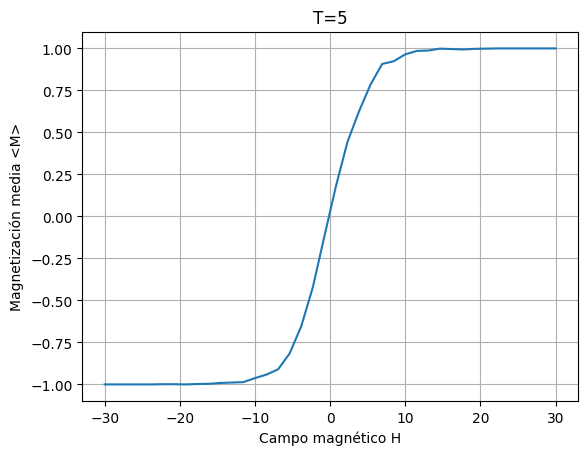

In [39]:
plt.plot(H_F,Magnet_mid)
plt.title("T=5")
plt.xlabel("Campo magnético H")
plt.ylabel("Magnetización media <M>")
plt.grid(True)
plt.show()

In [40]:
Magnet_mid2 = []
lattice_int2 = initial_lattice(N)

for H in H_F:
    Magnet_mid2.append(Net_magnet(metropolis_paramagnet(lattice_int2, steps, T_values[1], H)))

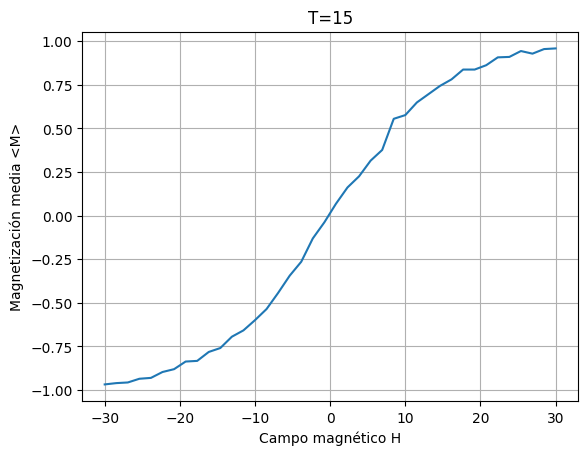

In [41]:
plt.plot(H_F,Magnet_mid2)
plt.title("T=15")
plt.xlabel("Campo magnético H")
plt.ylabel("Magnetización media <M>")
plt.grid(True)
plt.show()

In [42]:
Magnet_mid3 = []
lattice_int3 = initial_lattice(N)

for H in H_F:
    Magnet_mid3.append(Net_magnet(metropolis_paramagnet(lattice_int3, steps, T_values[1], H)))

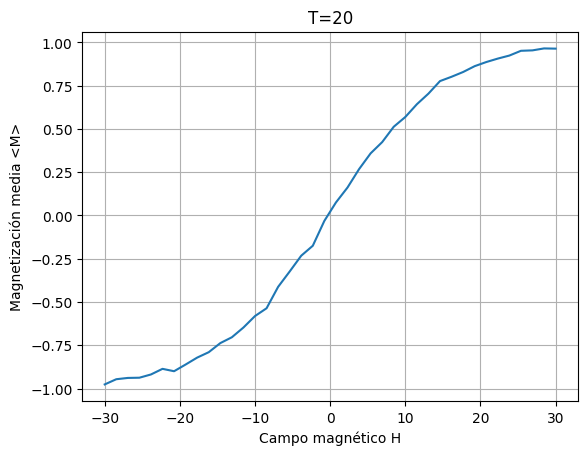

In [43]:
plt.plot(H_F,Magnet_mid3)
plt.title("T=20")
plt.xlabel("Campo magnético H")
plt.ylabel("Magnetización media <M>")
plt.grid(True)
plt.show()

# Solución exacta VS simulación

Lars Onsager demostro que la funcion de particion es:
$$
Q(\beta, N, 0)=\left[2\cosh(\beta J)e^{I}\right]^N
$$
Con

$$
I=(2\pi)^{-1}\int_{0}^{\pi} d\phi\,
\ln\left\{
\frac{1}{2}
\left[
1+\left(1-\kappa^2\sin^2\phi\right)^{1/2}
\right]
\right\}
$$
Y

$$
\kappa=\frac{2\sinh(2\beta J)}{\cosh^2(2\beta J)}.
$$

Luego para J=0 tengo que K=0, I = 0 and $Q=2^N$
Comenzamos con el Hamiltoniano sin interacción entre espines:

$$
E(\{s_i\})=-H\sum_{i=1}^{N}s_i,
\qquad s_i=\pm 1.
$$

La función de partición está dada por

$$
Q=
\sum_{s_1}\sum_{s_2}\cdots\sum_{s_N}
e^{-\beta E(\{s_i\})}.
$$

Sustituyendo la energía del sistema, obtenemos

$$
Q=
\sum_{s_1}\sum_{s_2}\cdots\sum_{s_N}
e^{\beta H\sum_{i=1}^{N}s_i}.
$$

Ahora usamos la propiedad exponencial

$$
e^{\beta H\sum_{i=1}^{N}s_i}
=
\prod_{i=1}^{N} e^{\beta Hs_i}.
$$

Por lo tanto,

$$
Q=
\sum_{s_1}\sum_{s_2}\cdots\sum_{s_N}
\prod_{i=1}^{N} e^{\beta Hs_i}.
$$

Como no existe acoplamiento entre los espines, las sumas se pueden separar:

$$
Q=
\prod_{i=1}^{N}
\left(
\sum_{s_i=\pm 1} e^{\beta Hs_i}
\right).
$$

Ahora calculamos la contribución de un solo espín:

$$
\sum_{s_i=\pm 1} e^{\beta Hs_i}
=
e^{\beta H(+1)}+e^{\beta H(-1)}.
$$

Entonces,

$$
\sum_{s_i=\pm 1} e^{\beta Hs_i}
=
e^{\beta H}+e^{-\beta H}.
$$

Por definición,

$$
\cosh x=\frac{e^x+e^{-x}}{2}.
$$

Así,

$$
e^{\beta H}+e^{-\beta H}
=
2\cosh(\beta H).
$$

Finalmente, la función de partición queda

$$
Q=
\left[2\cosh(\beta H)\right]^N.
$$



Luego por ecuaciones generales de la teoria tengo que
$$
\langle M\rangle =
\frac{1}{\beta}
\frac{\partial \ln Q}{\partial H}
$$

la magnetizacion de mi lattice clasica es
$$
\langle M\rangle = N\mu \tanh(\frac{\mu H}{Tκ} )
$$
En este caso usare unidades reducidas tomando $\mu$,$κ$=1 y la forma normalizada de mi funcion quedando de la forma
$$
\langle M\rangle = \tanh(\frac{H}{T} )
$$


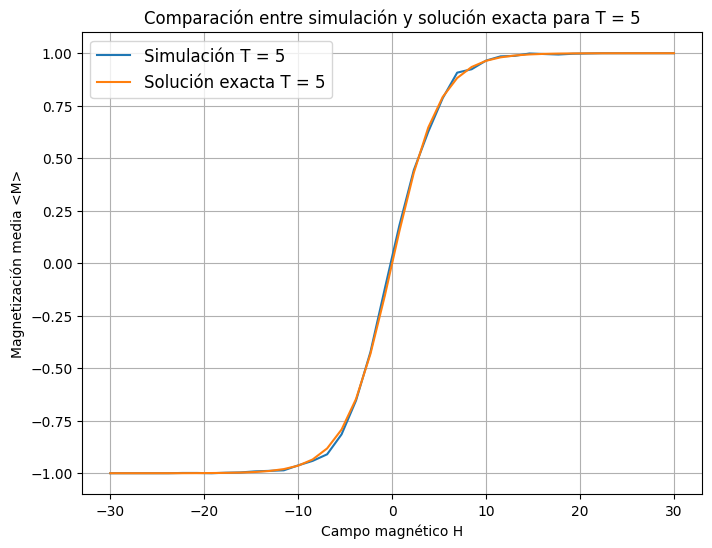

In [44]:
def Magnetizacion_canonica(H,T):
  return np.tanh(H/T)
plt.figure(figsize=(8, 6))

plt.plot(H_F, Magnet_mid, "-", label=f"Simulación T = {T_values[0]}")
plt.plot(
    H_F,
    Magnetizacion_canonica(H_F, T_values[0]),
    "-",
    label=f"Solución exacta T = {T_values[0]}"
)

plt.title("Comparación entre simulación y solución exacta para T = 5")
plt.xlabel("Campo magnético H")
plt.ylabel("Magnetización media <M>")

plt.legend(loc="best", fontsize=12, frameon=True)

plt.grid(True)
plt.show()

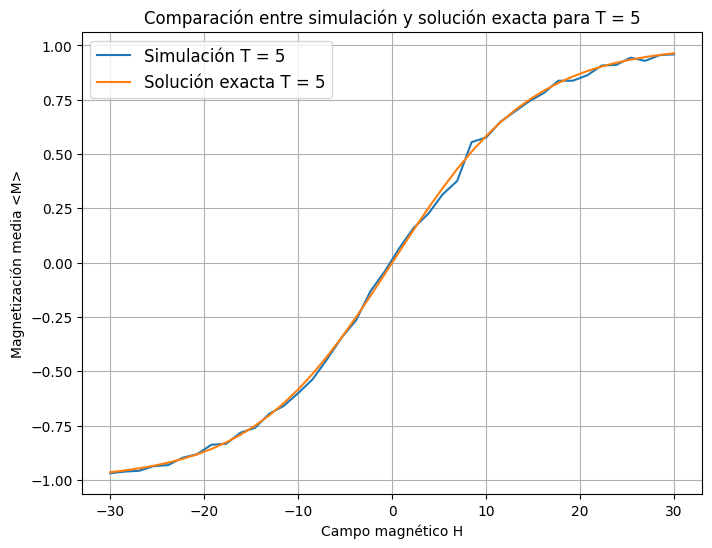

In [45]:
plt.figure(figsize=(8, 6))

plt.plot(H_F, Magnet_mid2, "-", label=f"Simulación T = {T_values[0]}")
plt.plot(
    H_F,
    Magnetizacion_canonica(H_F, T_values[1]),
    "-",
    label=f"Solución exacta T = {T_values[0]}"
)

plt.title("Comparación entre simulación y solución exacta para T = 5")
plt.xlabel("Campo magnético H")
plt.ylabel("Magnetización media <M>")

plt.legend(loc="best", fontsize=12, frameon=True)

plt.grid(True)
plt.show()

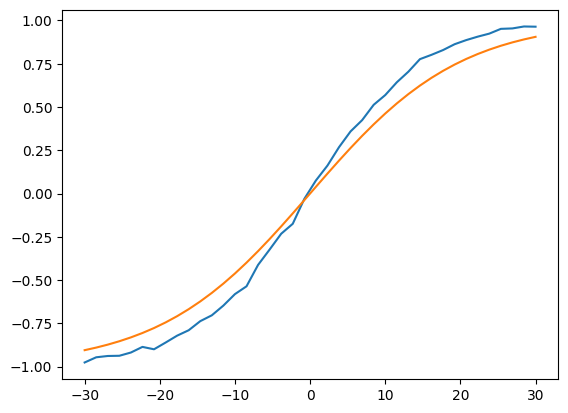

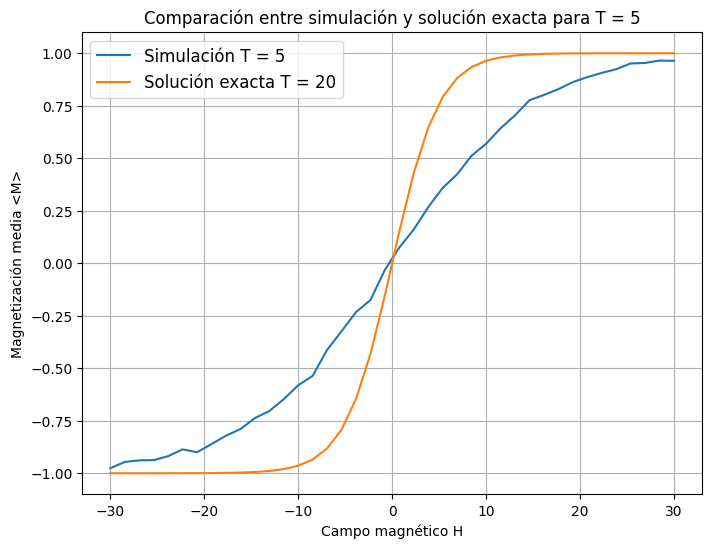

In [46]:
plt.plot(H_F,Magnet_mid3)
plt.plot(H_F,Magnetizacion_canonica(H_F,T_values[2]))
plt.figure(figsize=(8, 6))

plt.plot(H_F, Magnet_mid3, "-", label=f"Simulación T = {T_values[0]}")
plt.plot(
    H_F,
    Magnetizacion_canonica(H_F, T_values[0]),
    "-",
    label=f"Solución exacta T = {T_values[2]}"
)

plt.title("Comparación entre simulación y solución exacta para T = 5")
plt.xlabel("Campo magnético H")
plt.ylabel("Magnetización media <M>")

plt.legend(loc="best", fontsize=12, frameon=True)

plt.grid(True)
plt.show()

Por simple analizis de la grafica podemos ver que a mayor temperatura peor simula el modelo numerico, pero para valores pequeños es funciona muy bien